# Explainable Airfoil Noise Prediction with EBM

## Problem

Aircraft wings, wind-turbine blades, fans, and propellers can generate aerodynamic noise when turbulent airflow interacts with their surfaces.

This project predicts the scaled sound-pressure level of an airfoil using wind-tunnel operating conditions.

The practical questions are:

1. How accurately can airfoil noise be predicted?
2. Which physical variables contribute most strongly to noise?
3. Are the relationships linear or nonlinear?
4. Which operating variables interact with one another?
5. Why does the model make a particular prediction?
6. Can it generalize to airfoil operating configurations not seen in training?

## Method

The main model is an Explainable Boosting Machine regressor. An EBM represents a prediction as:

$$
\hat{y}=\beta_0+\sum_j f_j(x_j)+\sum_{(j,k)\in I}f_{jk}(x_j,x_k)
$$

where $\beta_0$ is the baseline prediction, $f_j(x_j)$ is one feature's learned contribution, and $f_{jk}(x_j,x_k)$ is an interaction contribution. Each contribution is measured in predicted decibels.

Unlike an ordinary linear model, each feature can have a nonlinear shape. Unlike most black-box ensembles, each prediction can be decomposed directly into understandable contributions.


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42


## 1. Load the NASA airfoil self-noise data

The dataset contains measurements from aerodynamic and acoustic wind-tunnel experiments on NACA 0012 airfoil sections.

### Input variables

- `frequency_hz`: acoustic frequency being measured.
- `angle_of_attack_deg`: angle between the airfoil and airflow.
- `chord_length_m`: distance from the leading edge to the trailing edge.
- `free_stream_velocity_m_s`: airflow velocity.
- `displacement_thickness_m`: boundary-layer displacement thickness.

### Target

- `sound_pressure_db`: scaled sound-pressure level in decibels.

Source: Brooks, Pope, and Marcolini (1989), [Airfoil Self-Noise](https://doi.org/10.24432/C5VW2C), UCI Machine Learning Repository.


In [3]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00291/"
    "airfoil_self_noise.dat"
)

columns = [
    "frequency_hz",
    "angle_of_attack_deg",
    "chord_length_m",
    "free_stream_velocity_m_s",
    "displacement_thickness_m",
    "sound_pressure_db"
]

data = pd.read_csv(DATA_URL, sep="\t", header=None, names=columns)

print(f"Rows:    {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
display(data.head())


Rows:    1,503
Columns: 6


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_m_s,displacement_thickness_m,sound_pressure_db
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [4]:
quality_report = pd.DataFrame({
    "dtype": data.dtypes,
    "missing": data.isna().sum(),
    "unique_values": data.nunique(),
    "minimum": data.min(),
    "maximum": data.max()
})

print(f"Duplicate rows: {data.duplicated().sum()}")
display(quality_report.round(5))
display(data.describe().T.round(4))


Duplicate rows: 0


,dtype,missing,unique_values,minimum,maximum
frequency_hz,int64,0,21,200.0000,20000.00000
angle_of_attack_deg,float64,0,27,0.0000,22.20000
chord_length_m,float64,0,6,0.0254,0.30480
free_stream_velocity_m_s,float64,0,4,31.7000,71.30000
displacement_thickness_m,float64,0,105,0.0004,0.05841
sound_pressure_db,float64,0,1456,103.3800,140.98700


,count,mean,std,min,25%,50%,75%,max
frequency_hz,1503.0,2886.3806,3152.5731,200.0000,800.0000,1600.0000,4000.0000,20000.0000
angle_of_attack_deg,1503.0,6.7823,5.9181,0.0000,2.0000,5.4000,9.9000,22.2000
chord_length_m,1503.0,0.1365,0.0935,0.0254,0.0508,0.1016,0.2286,0.3048
free_stream_velocity_m_s,1503.0,50.8607,15.5728,31.7000,39.6000,39.6000,71.3000,71.3000
displacement_thickness_m,1503.0,0.0111,0.0132,0.0004,0.0025,0.0050,0.0156,0.0584
sound_pressure_db,1503.0,124.8359,6.8987,103.3800,120.1910,125.7210,129.9955,140.9870


## 2. Explore the experimental measurements

The variables use very different physical scales. EBM does not require feature standardization because it learns each feature through ordered bins. Ridge regression will require standardization.


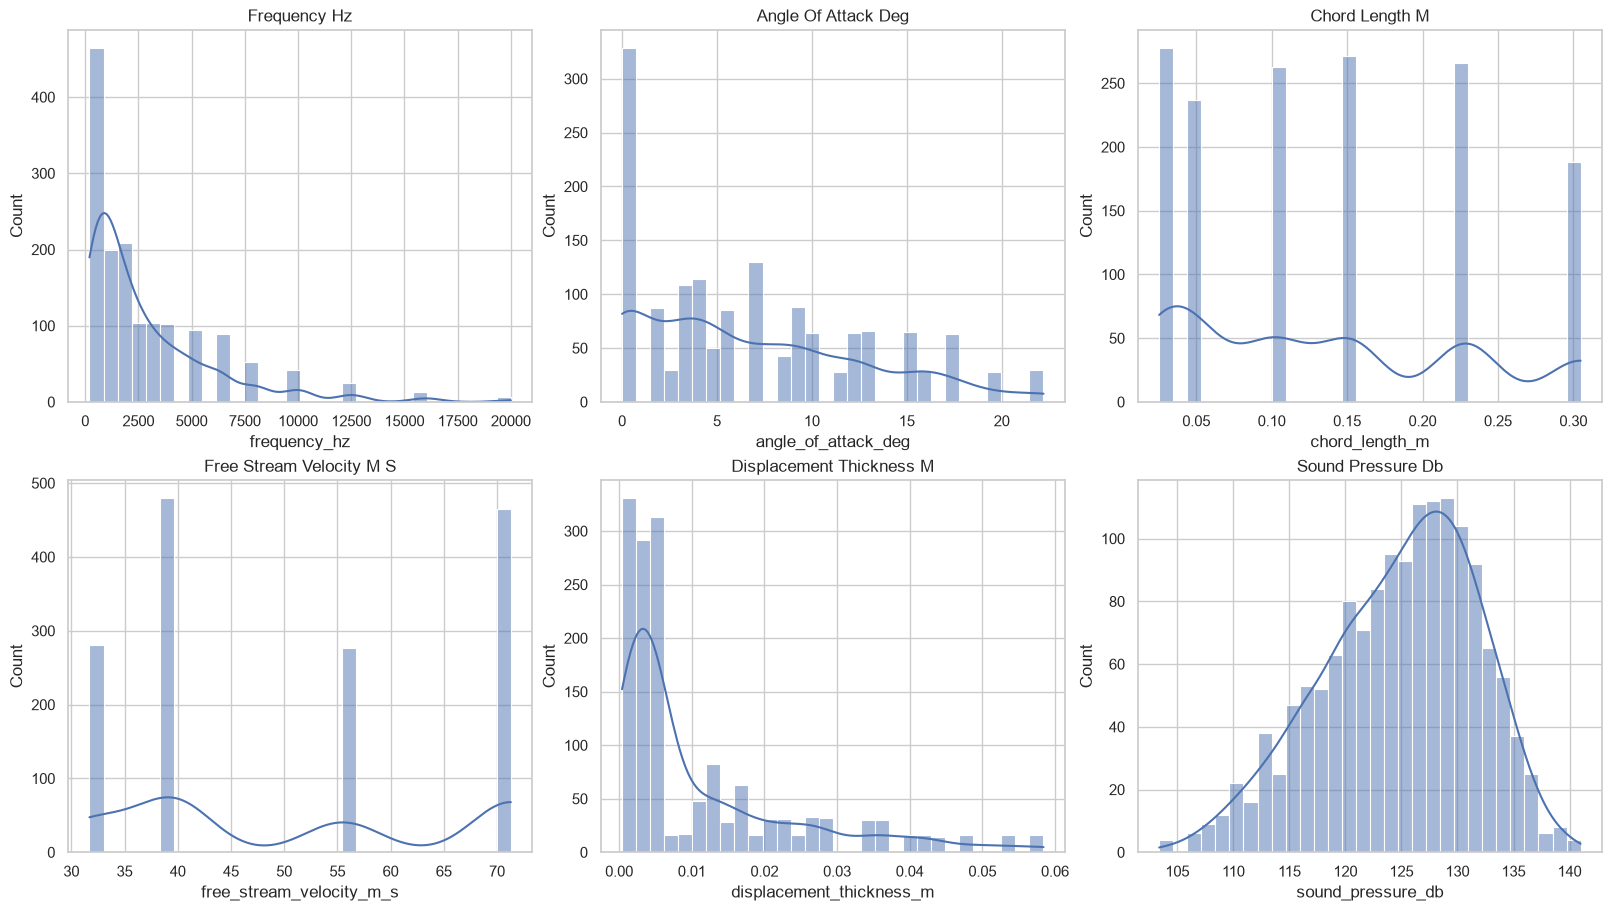

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for column, ax in zip(columns, axes.flat):
    sns.histplot(data=data, x=column, bins=30, kde=True, ax=ax)
    ax.set_title(column.replace("_", " ").title())

plt.show()


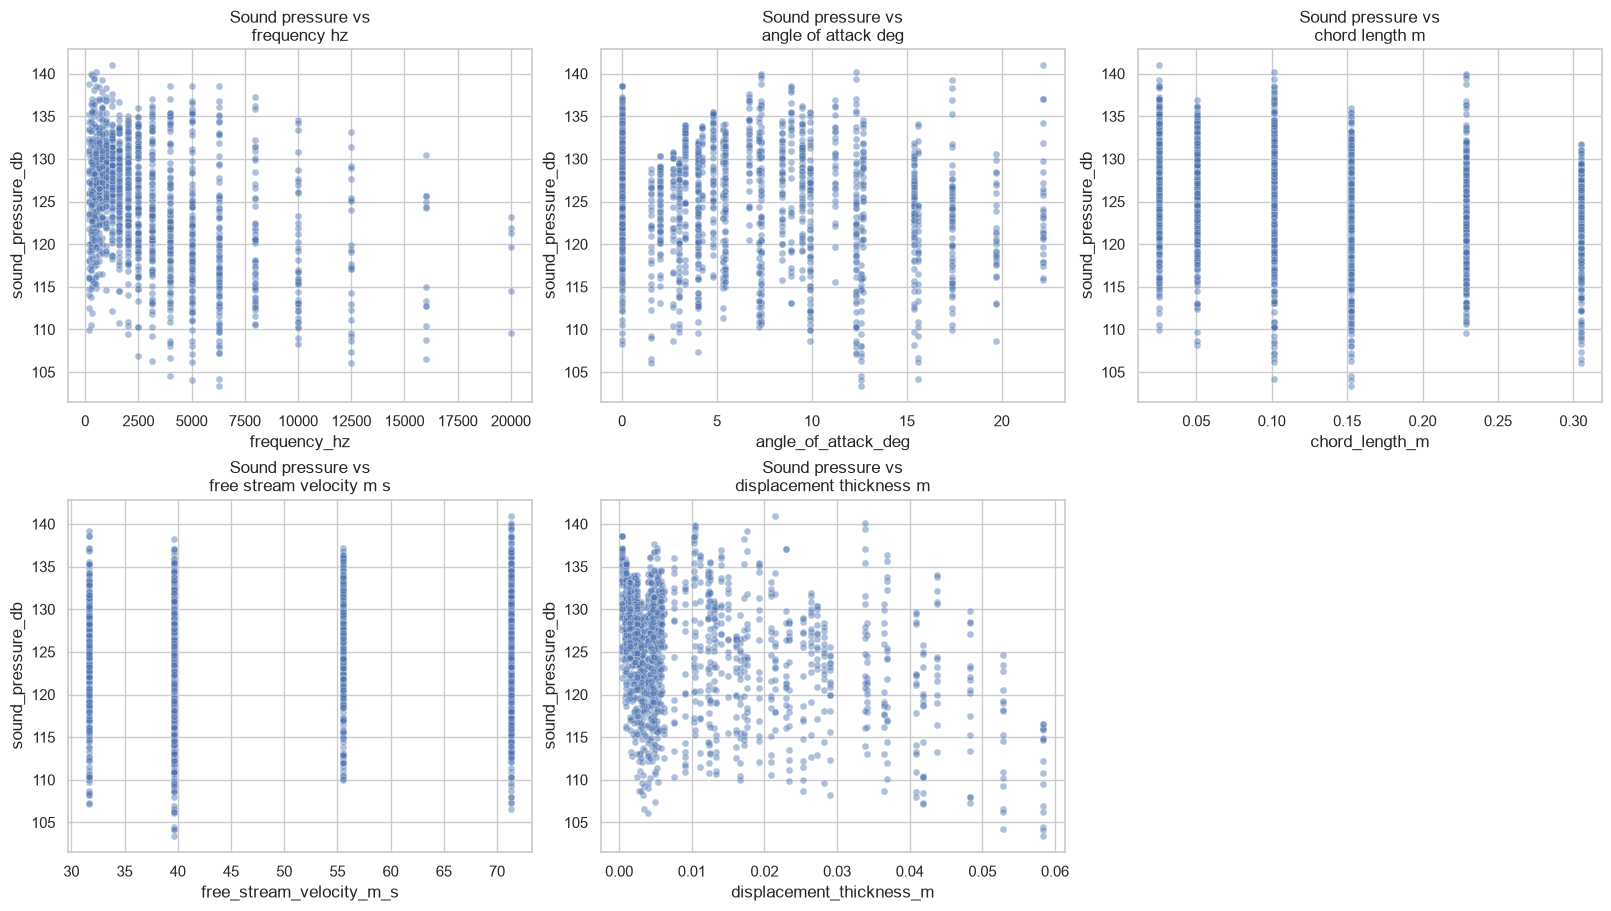

In [6]:
features = columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for feature, ax in zip(features, axes.flat):
    sns.scatterplot(
        data=data,
        x=feature,
        y="sound_pressure_db",
        alpha=0.45,
        s=25,
        ax=ax
    )
    ax.set_title(f"Sound pressure vs\n{feature.replace('_', ' ')}")

axes.flat[-1].axis("off")
plt.show()


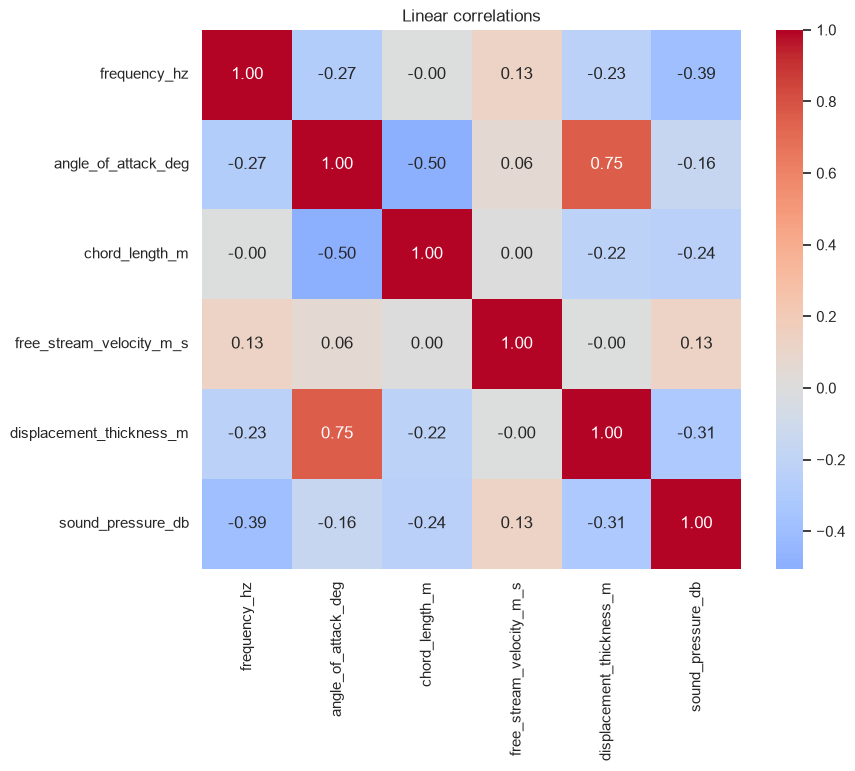

In [7]:
correlation = data.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Linear correlations")
plt.show()


## Data exploration

The dataset contains **1,503 observations**, five input variables, and one continuous target. There are **no missing values and no duplicate rows**, so no imputation or duplicate removal is required. Scaled sound pressure ranges from **103.380 to 140.987 dB**, with a mean of **124.836 dB**, median of **125.721 dB**, and standard deviation of **6.899 dB**. Its distribution is unimodal but extends further toward lower sound-pressure values.

Several predictors are experimental settings rather than continuously sampled variables. Frequency has 21 levels and is strongly right-skewed from 200 to 20,000 Hz; chord length has six values; and free-stream velocity has only four. Angle of attack has 27 values and is concentrated at lower angles. Displacement thickness has 105 values but is also strongly right-skewed, with most measurements near the lower end of its 0.0004–0.0584 m range.

The scatterplots show that sound pressure generally declines with frequency and displacement thickness, but the wide vertical bands indicate that these relationships depend on the remaining operating conditions. Frequency has the strongest target correlation (**−0.39**), followed by displacement thickness (**−0.31**), chord length (**−0.24**), angle of attack (**−0.16**), and velocity (**+0.13**). Angle and displacement thickness are strongly related to each other (**0.75**), while angle and chord length have a correlation of **−0.50**. These dependencies make unadjusted correlations difficult to interpret physically. A weak linear correlation does not make a feature unimportant to EBM because EBM can learn nonlinear effects and interactions that correlation cannot represent.


## 3. Create an honest grouped train-test split

A random row split would be relatively easy because measurements from the same physical airfoil configuration could appear in both training and testing. The only difference between two such rows might be measurement frequency.

To test more realistic generalization, an operating configuration is defined by angle of attack, chord length, airflow velocity, and displacement thickness. All frequencies belonging to one configuration are assigned entirely to either training or testing. The test set therefore contains physical configurations the model has never seen during training.


In [8]:
X = data[features].copy()
y = data["sound_pressure_db"].copy()

configuration_columns = [
    "angle_of_attack_deg",
    "chord_length_m",
    "free_stream_velocity_m_s",
    "displacement_thickness_m"
]

configuration_id = data.groupby(
    configuration_columns,
    sort=False
).ngroup()

print("Unique operating configurations:", configuration_id.nunique())


Unique operating configurations: 106


In [9]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_index, test_index = next(
    splitter.split(X, y, groups=configuration_id)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()
y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_groups = set(configuration_id.iloc[train_index])
test_groups = set(configuration_id.iloc[test_index])

print(f"Training rows:           {len(X_train):,}")
print(f"Testing rows:            {len(X_test):,}")
print(f"Training configurations: {len(train_groups)}")
print(f"Testing configurations:  {len(test_groups)}")
print(f"Overlapping groups:      {len(train_groups & test_groups)}")

assert train_groups.isdisjoint(test_groups)


Training rows:           1,186
Testing rows:            317
Training configurations: 84
Testing configurations:  22
Overlapping groups:      0


In [10]:
split_summary = pd.DataFrame({
    "set": ["Training", "Testing"],
    "rows": [len(X_train), len(X_test)],
    "configurations": [len(train_groups), len(test_groups)],
    "target_mean_db": [y_train.mean(), y_test.mean()],
    "target_std_db": [y_train.std(), y_test.std()]
})

display(split_summary.round(3))


,set,rows,configurations,target_mean_db,target_std_db
0,Training,1186,84,125.174,6.84
1,Testing,317,22,123.569,6.98


## 4. Train baseline and comparison models

- **Mean baseline:** predicts the training-set mean for every experiment.
- **Ridge regression:** tests whether a regularized linear relationship is sufficient.
- **Random forest:** provides a strong nonlinear but less transparent benchmark.
- **EBM — main effects:** learns nonlinear single-feature functions but assumes their effects are additive.
- **EBM — interactions:** also learns three two-feature effects.

Comparing the two EBM versions isolates the predictive value of interactions.


In [11]:
models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Ridge regression": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "EBM — main effects": ExplainableBoostingRegressor(
        interactions=0,
        outer_bags=8,
        validation_size=0.15,
        learning_rate=0.03,
        max_rounds=5000,
        early_stopping_rounds=100,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "EBM — 3 interactions": ExplainableBoostingRegressor(
        interactions=3,
        outer_bags=8,
        validation_size=0.15,
        learning_rate=0.03,
        max_rounds=5000,
        early_stopping_rounds=100,
        random_state=RANDOM_STATE,
        n_jobs=1
    )
}


In [12]:
predictions = {}
metric_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    predictions[model_name] = prediction

    metric_rows.append({
        "model": model_name,
        "MAE_db": mean_absolute_error(y_test, prediction),
        "RMSE_db": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction)
    })

model_results = (
    pd.DataFrame(metric_rows)
    .sort_values("RMSE_db")
    .reset_index(drop=True)
)

display(model_results.round(4))


,model,MAE_db,RMSE_db,R2
0,Random forest,2.5552,3.5619,0.7388
1,EBM — 3 interactions,2.5328,3.6577,0.7246
2,EBM — main effects,3.5527,4.7666,0.5322
3,Ridge regression,3.6958,4.9783,0.4897
4,Mean baseline,5.6788,7.1518,-0.0530


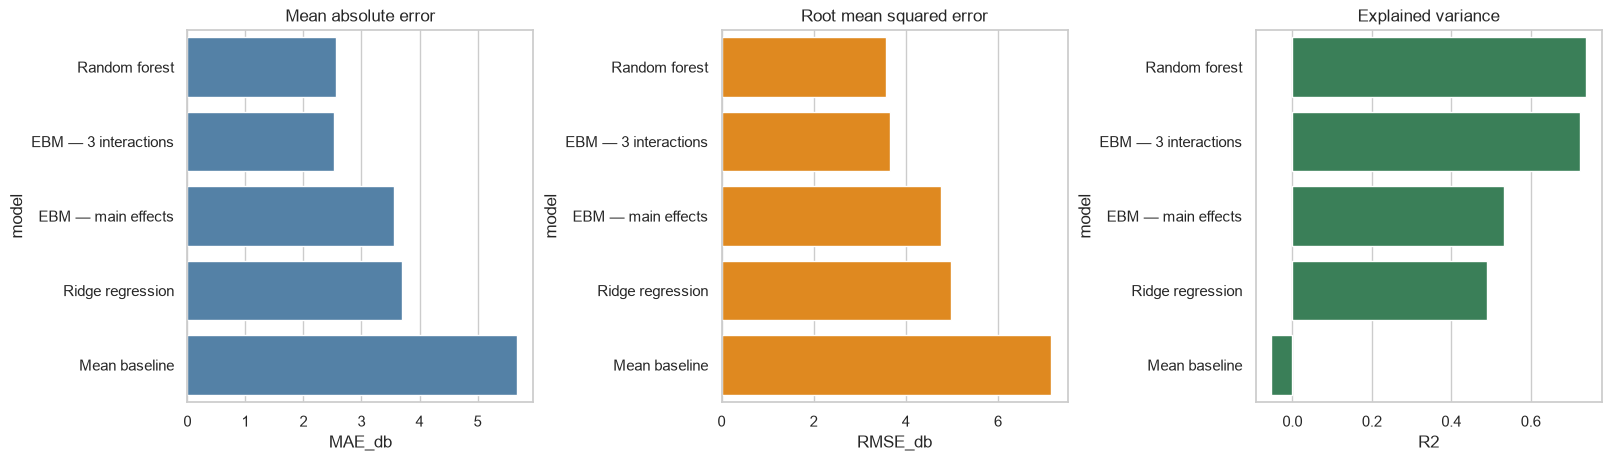

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

sns.barplot(data=model_results, x="MAE_db", y="model", ax=axes[0], color="steelblue")
sns.barplot(data=model_results, x="RMSE_db", y="model", ax=axes[1], color="darkorange")
sns.barplot(data=model_results, x="R2", y="model", ax=axes[2], color="seagreen")

axes[0].set_title("Mean absolute error")
axes[1].set_title("Root mean squared error")
axes[2].set_title("Explained variance")

plt.show()


## Model comparison

The split contains **1,186 training rows from 84 configurations** and **317 test rows from 22 entirely unseen configurations**, with zero group overlap. The test target mean is 123.569 dB compared with 125.174 dB in training, although their standard deviations are similar. This group-level distribution shift helps explain why the mean baseline has a negative $R^2$ (**−0.0530**).

The interaction EBM achieves the lowest MAE at **2.5328 dB**. The random forest is marginally worse on MAE at 2.5552 dB, but has the best RMSE (**3.5619 dB**) and $R^2$ (**0.7388**). The interaction EBM follows closely with RMSE **3.6577 dB** and $R^2$ **0.7246**: its RMSE is only 2.7% higher and its $R^2$ is lower by 0.0142. It therefore offers nearly the same generalization performance while exposing its nonlinear functions and prediction contributions directly.

Interactions are essential in this problem. Adding three interactions reduces EBM MAE from **3.5527 to 2.5328 dB** (28.7%), reduces RMSE from **4.7666 to 3.6577 dB** (23.3%), and raises $R^2$ from **0.5322 to 0.7246**. The main-effects EBM is only moderately better than Ridge regression, whereas the interaction EBM reduces Ridge MAE by 31.5% and RMSE by 26.5%. It also reduces the mean-baseline MAE by 55.4%.

This grouped evaluation is intentionally harder than a random row split because every test configuration combines angle, chord, velocity, and displacement thickness in a way absent from training. Performance therefore reflects interpolation across new physical configurations rather than memorization of the same configurations at different frequencies.


## 5. Inspect EBM residuals

The following analysis focuses on the interaction EBM. A residual is defined as $e_i=y_i-\hat{y}_i$.

- A positive residual means the model underpredicted noise.
- A negative residual means the model overpredicted noise.
- A residual near zero represents an accurate prediction.


In [14]:
ebm = models["EBM — 3 interactions"]
ebm_prediction = predictions["EBM — 3 interactions"]

test_results = X_test.copy()
test_results["actual_db"] = y_test
test_results["predicted_db"] = ebm_prediction
test_results["residual_db"] = test_results["actual_db"] - test_results["predicted_db"]
test_results["absolute_error_db"] = test_results["residual_db"].abs()

display(test_results.head().round(4))


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_m_s,displacement_thickness_m,actual_db,predicted_db,residual_db,absolute_error_db
0,800,0.0,0.3048,71.3,0.0027,126.201,131.5033,-5.3023,5.3023
1,1000,0.0,0.3048,71.3,0.0027,125.201,130.6403,-5.4393,5.4393
2,1250,0.0,0.3048,71.3,0.0027,125.951,129.3554,-3.4044,3.4044
3,1600,0.0,0.3048,71.3,0.0027,127.591,128.1996,-0.6086,0.6086
4,2000,0.0,0.3048,71.3,0.0027,127.461,127.1912,0.2698,0.2698


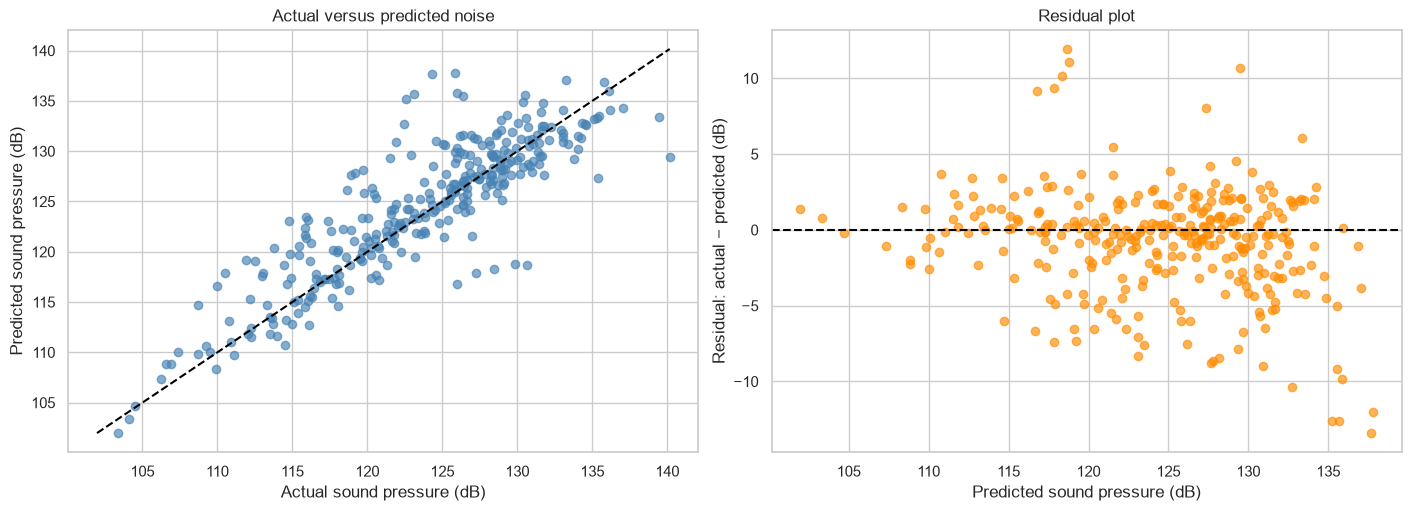

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].scatter(
    test_results["actual_db"],
    test_results["predicted_db"],
    alpha=0.65,
    color="steelblue"
)

minimum = min(test_results["actual_db"].min(), test_results["predicted_db"].min())
maximum = max(test_results["actual_db"].max(), test_results["predicted_db"].max())
axes[0].plot([minimum, maximum], [minimum, maximum], linestyle="--", color="black")
axes[0].set(
    title="Actual versus predicted noise",
    xlabel="Actual sound pressure (dB)",
    ylabel="Predicted sound pressure (dB)"
)

axes[1].scatter(
    test_results["predicted_db"],
    test_results["residual_db"],
    alpha=0.65,
    color="darkorange"
)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(
    title="Residual plot",
    xlabel="Predicted sound pressure (dB)",
    ylabel="Residual: actual − predicted (dB)"
)

plt.show()


In [16]:
target_bins = pd.qcut(test_results["actual_db"], q=4, duplicates="drop")

error_by_target = (
    test_results
    .assign(actual_noise_range=target_bins)
    .groupby("actual_noise_range", observed=True)
    .agg(
        observations=("actual_db", "size"),
        mean_actual_db=("actual_db", "mean"),
        MAE_db=("absolute_error_db", "mean"),
        mean_residual_db=("residual_db", "mean")
    )
    .reset_index()
)

largest_errors = (
    test_results
    .sort_values("absolute_error_db", ascending=False)
    .head(10)
)

display(error_by_target.round(3))
display(largest_errors.round(4))


,actual_noise_range,observations,mean_actual_db,MAE_db,mean_residual_db
0,"(103.37899999999999, 118.743]",80,114.081,2.627,-1.660
1,"(118.743, 124.852]",79,121.800,2.696,-1.853
2,"(124.852, 128.723]",79,126.823,2.496,-0.737
3,"(128.723, 140.158]",79,131.693,2.310,1.046


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_m_s,displacement_thickness_m,actual_db,predicted_db,residual_db,absolute_error_db
1153,800,17.4,0.0254,71.3,0.0161,124.276,137.6797,-13.4037,13.4037
1152,630,17.4,0.0254,71.3,0.0161,122.606,135.2317,-12.6257,12.6257
1170,800,17.4,0.0254,55.5,0.0166,123.091,135.6968,-12.6058,12.6058
1154,1000,17.4,0.0254,71.3,0.0161,125.816,137.7998,-11.9838,11.9838
951,400,19.7,0.0508,39.6,0.0365,130.614,118.6809,11.9331,11.9331
950,315,19.7,0.0508,39.6,0.0365,129.864,118.7854,11.0786,11.0786
1413,500,12.3,0.1016,71.3,0.0338,140.158,129.4654,10.6926,10.6926
1169,630,17.4,0.0254,55.5,0.0166,122.411,132.7455,-10.3345,10.3345
952,500,19.7,0.0508,39.6,0.0365,128.444,118.3134,10.1306,10.1306
1171,1000,17.4,0.0254,55.5,0.0166,126.001,135.8323,-9.8313,9.8313


## Residual analysis

Most observations follow the actual-versus-predicted diagonal, confirming that the EBM captures much of the variation in noise. However, several clear outliers remain, and the residual spread is widest through the central prediction range. The model also shows regression toward the training mean: it overpredicts quieter observations and tends to underpredict the loudest observations.

The lowest three actual-noise quartiles have mean residuals of **−1.660, −1.853, and −0.737 dB**, respectively, so these ranges are overpredicted on average. The highest quartile has a mean residual of **+1.046 dB**, indicating average underprediction. MAE is nevertheless fairly consistent across quartiles, ranging from 2.310 to 2.696 dB. The second quartile, 118.743–124.852 dB, has the largest MAE (**2.696 dB**), while the loudest quartile has the smallest (**2.310 dB**).

The largest errors are not randomly distributed. Many occur at low frequencies of 630–1,000 Hz with a **17.4° angle, 0.0254 m chord, and approximately 0.016 m displacement thickness**, where the model overpredicts by roughly 10–13 dB. Another group at 315–500 Hz, 19.7°, 0.0508 m chord, and 0.0365 m thickness is underpredicted by about 10–12 dB. These combinations lie in interaction-sensitive parts of the feature space and belong to unseen configurations, so the model must infer their joint effect from different training configurations.


## 6. Global EBM explanation

EBM assigns an importance to every main effect and interaction. Importance measures the average absolute contribution of a term to predictions. It does not prove that a variable causes changes in noise.

A feature contribution above zero raises predicted noise relative to the intercept. A contribution below zero lowers it. The shaded bands represent variation across EBM's outer bags, not full prediction intervals.


,term,importance,term_type
0,frequency_hz,3.4034,Main effect
7,frequency_hz & displacement_thickness_m,2.7517,Interaction
2,chord_length_m,2.3363,Main effect
6,frequency_hz & chord_length_m,1.7452,Interaction
3,free_stream_velocity_m_s,1.4102,Main effect
1,angle_of_attack_deg,1.3898,Main effect
4,displacement_thickness_m,1.2725,Main effect
5,frequency_hz & angle_of_attack_deg,1.1534,Interaction


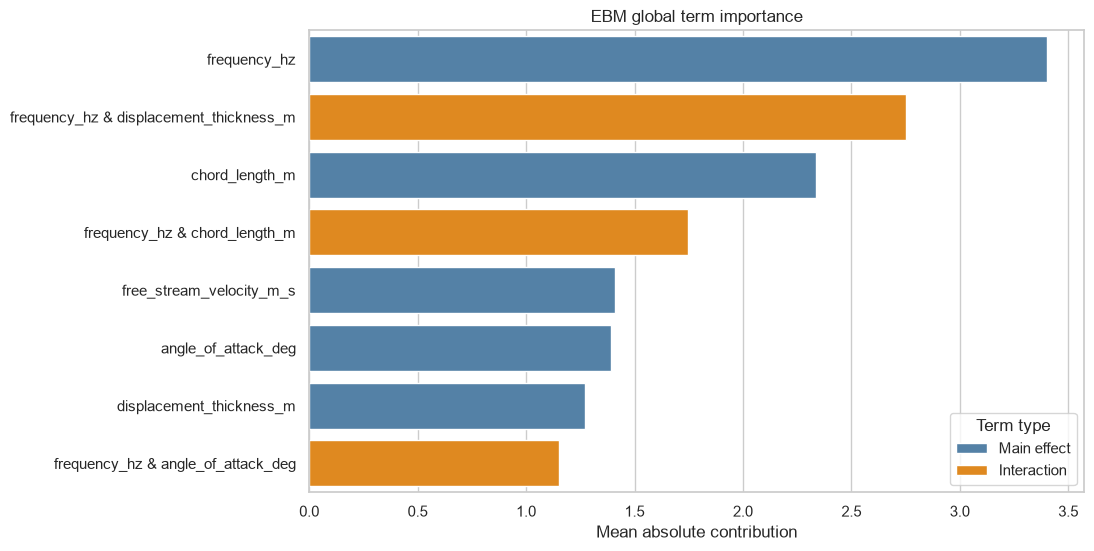

In [17]:
term_importance = pd.DataFrame({
    "term": ebm.term_names_,
    "importance": ebm.term_importances(),
    "term_type": [
        "Interaction" if len(term) > 1 else "Main effect"
        for term in ebm.term_features_
    ]
}).sort_values("importance", ascending=False)

display(term_importance.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=term_importance,
    x="importance",
    y="term",
    hue="term_type",
    dodge=False,
    palette={"Main effect": "steelblue", "Interaction": "darkorange"}
)
plt.title("EBM global term importance")
plt.xlabel("Mean absolute contribution")
plt.ylabel("")
plt.legend(title="Term type")
plt.show()


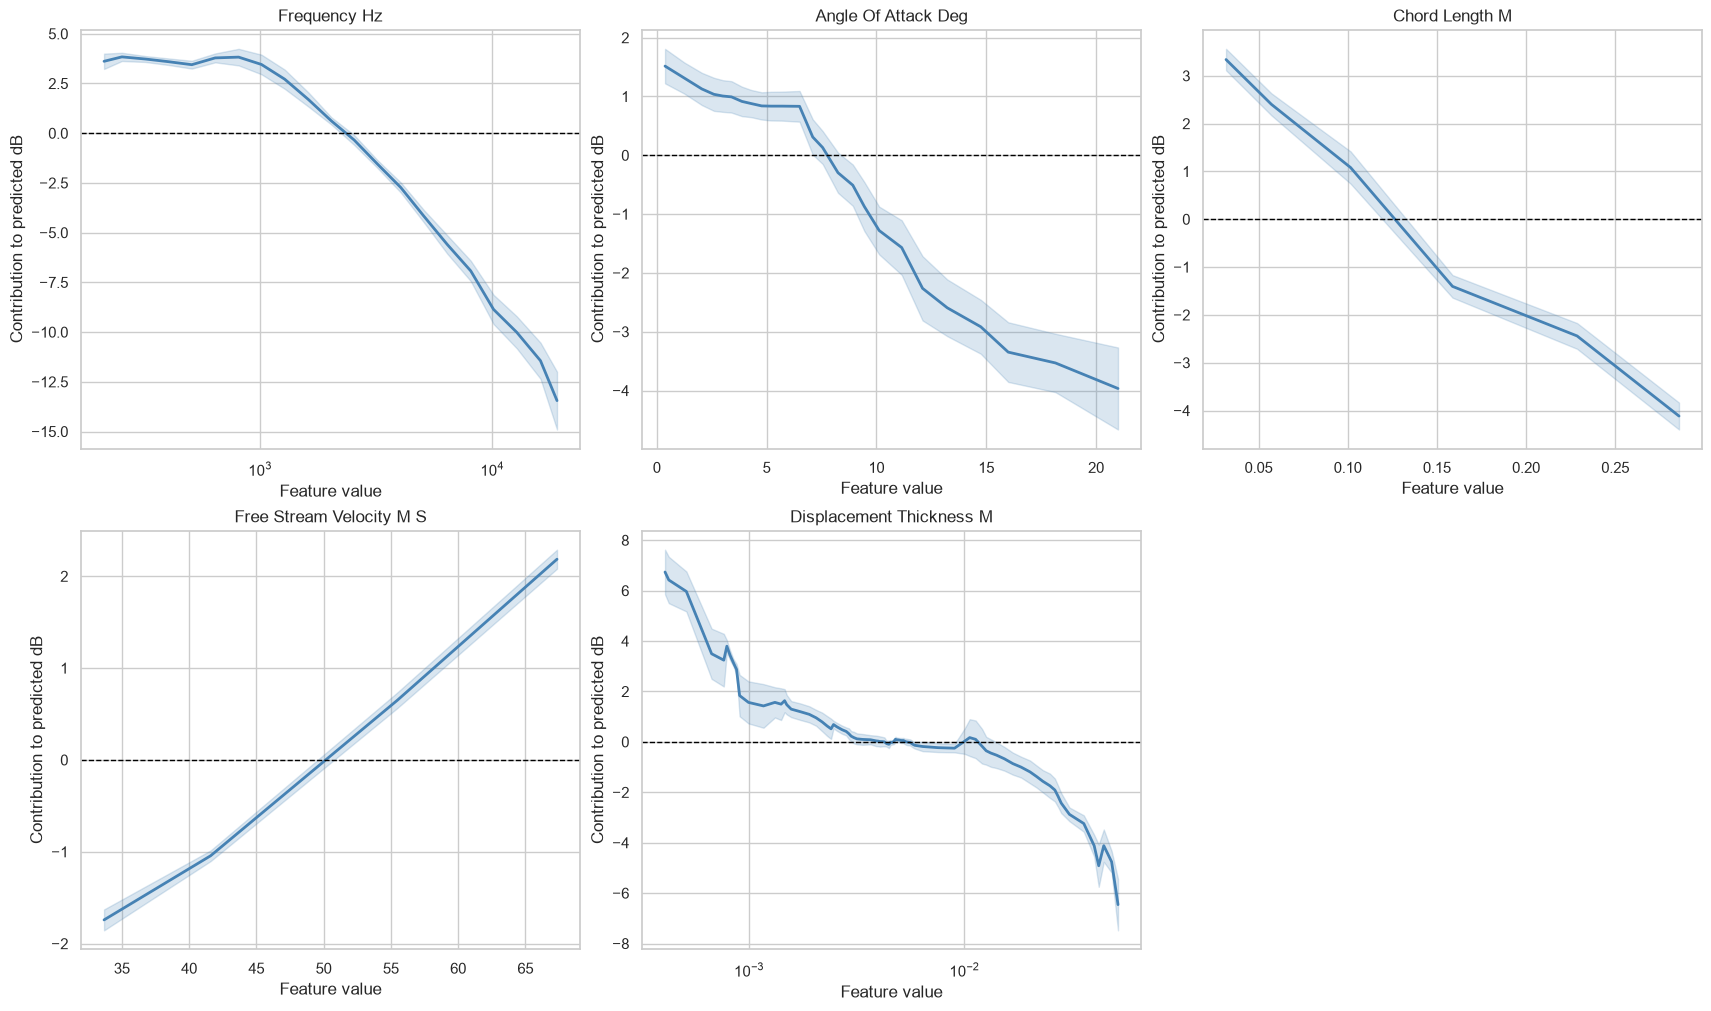

In [18]:
global_explanation = ebm.explain_global()
main_effect_indices = [
    index for index, term in enumerate(ebm.term_features_)
    if len(term) == 1
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)

for ax, term_index in zip(axes.flat, main_effect_indices):
    explanation = global_explanation.data(term_index)
    bin_edges = np.asarray(explanation["names"], dtype=float)
    contributions = np.asarray(explanation["scores"], dtype=float)
    lower = np.asarray(explanation["lower_bounds"], dtype=float)
    upper = np.asarray(explanation["upper_bounds"], dtype=float)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.plot(bin_centres, contributions, color="steelblue", linewidth=2)
    ax.fill_between(bin_centres, lower, upper, color="steelblue", alpha=0.2)
    ax.axhline(0, linestyle="--", color="black", linewidth=1)

    feature_name = ebm.term_names_[term_index]
    ax.set(
        title=feature_name.replace("_", " ").title(),
        xlabel="Feature value",
        ylabel="Contribution to predicted dB"
    )

    if feature_name in {"frequency_hz", "displacement_thickness_m"}:
        ax.set_xscale("log")

for ax in axes.flat[len(main_effect_indices):]:
    ax.axis("off")

plt.show()


## 7. Inspect the strongest learned interaction

An interaction means the contribution of one variable depends on another variable. Warm regions in the heatmap increase predicted decibels, cool regions decrease them, and values near zero add little joint effect beyond the two main effects.


Strongest interaction: frequency_hz & displacement_thickness_m


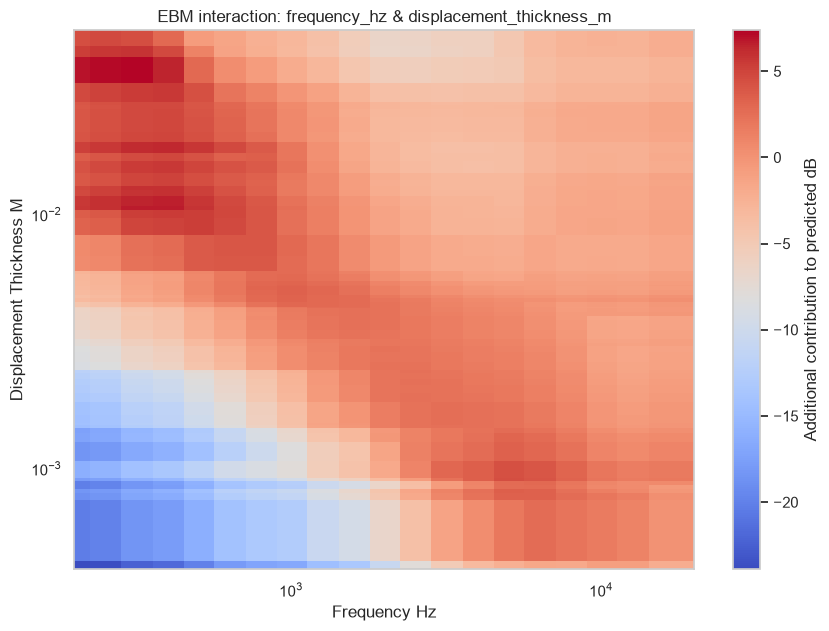

In [19]:
interaction_indices = [
    index for index, term in enumerate(ebm.term_features_)
    if len(term) > 1
]

strongest_interaction_index = max(
    interaction_indices,
    key=lambda index: ebm.term_importances()[index]
)

interaction_name = ebm.term_names_[strongest_interaction_index]
interaction_data = global_explanation.data(strongest_interaction_index)

x_edges = np.asarray(interaction_data["left_names"], dtype=float)
y_edges = np.asarray(interaction_data["right_names"], dtype=float)
interaction_scores = np.asarray(interaction_data["scores"], dtype=float)

x_feature_index, y_feature_index = ebm.term_features_[strongest_interaction_index]
x_feature = ebm.feature_names_in_[x_feature_index]
y_feature = ebm.feature_names_in_[y_feature_index]

print(f"Strongest interaction: {interaction_name}")

fig, ax = plt.subplots(figsize=(10, 7))
mesh = ax.pcolormesh(
    x_edges,
    y_edges,
    interaction_scores.T,
    cmap="coolwarm",
    shading="flat"
)

ax.set(
    title=f"EBM interaction: {interaction_name}",
    xlabel=x_feature.replace("_", " ").title(),
    ylabel=y_feature.replace("_", " ").title()
)

if x_feature in {"frequency_hz", "displacement_thickness_m"}:
    ax.set_xscale("log")
if y_feature in {"frequency_hz", "displacement_thickness_m"}:
    ax.set_yscale("log")

colorbar = fig.colorbar(mesh, ax=ax)
colorbar.set_label("Additional contribution to predicted dB")
plt.show()


## Global explanation

Frequency is the most important main effect (**3.4034**), followed by chord length (2.3363), velocity (1.4102), angle of attack (1.3898), and displacement thickness (1.2725). Importantly, the **frequency × displacement-thickness interaction** has importance 2.7517, making it the second most influential term overall. The other selected interactions are frequency × chord length (1.7452) and frequency × angle of attack (1.1534). All three interactions involve frequency, showing that a frequency's expected sound level depends substantially on the airfoil and airflow conditions.

The frequency function is clearly nonlinear. Frequencies below roughly 1,000 Hz add about 3–4 dB relative to the intercept, the contribution crosses zero around 2,000 Hz, and then declines sharply to approximately −13 dB at the highest frequencies. Angle of attack is positive at low angles, remains near +1 dB through approximately 4–7°, crosses zero near 7–8°, and falls to about −4 dB at 22°. Chord length follows a mostly monotonic decline from roughly +3.3 dB at 0.0254 m to about −4.2 dB near 0.3048 m.

Free-stream velocity has the opposite pattern: its contribution rises almost monotonically from about −1.7 dB at 31.7 m/s to +2.2 dB at 71.3 m/s, crossing zero near 50 m/s. Displacement thickness declines from approximately +6–7 dB at the thinnest boundary layers to around zero in the middle of its range and below −6 dB at the thickest values. Its curve is less smooth and its uncertainty widens at the extremes, where observations are sparse. Angle uncertainty similarly becomes wider at the largest angles.

The strongest interaction heatmap adds information that the individual curves cannot express. At low frequencies, very thin displacement layers produce a large negative interaction contribution, whereas thicker layers produce a positive contribution. At higher frequencies this contrast changes and becomes less extreme. The interaction explains why the additive EBM performs much worse: the effect of frequency cannot be treated as fixed across displacement thickness. These are conditional patterns learned from this dataset, not causal effects.


## 8. Decompose individual predictions

For one observation, EBM calculates:

$$
\text{prediction}=\text{intercept}+\text{main-effect contributions}+\text{interaction contributions}
$$

We compare the most accurately predicted test experiment with the experiment having the largest error.


In [20]:
case_indices = {
    "Most accurate prediction": test_results["absolute_error_db"].idxmin(),
    "Largest prediction error": test_results["absolute_error_db"].idxmax()
}

intercept = float(np.asarray(ebm.intercept_).squeeze())
local_tables = {}

for case_name, row_index in case_indices.items():
    row = X_test.loc[[row_index]]
    contributions = ebm.eval_terms(row)[0]
    prediction = float(ebm.predict(row)[0])
    actual = float(y_test.loc[row_index])

    local_table = pd.DataFrame({
        "term": ebm.term_names_,
        "contribution_db": contributions
    })
    local_table["absolute_contribution"] = local_table["contribution_db"].abs()
    local_table = local_table.sort_values("absolute_contribution", ascending=False)
    local_tables[case_name] = local_table

    print(f"\n{case_name}")
    print(f"Actual:        {actual:.3f} dB")
    print(f"Prediction:    {prediction:.3f} dB")
    print(f"Error:         {actual - prediction:.3f} dB")
    print(f"Intercept:     {intercept:.3f} dB")
    print(f"Reconstructed: {intercept + contributions.sum():.3f} dB")
    display(row.round(5))
    display(local_table[["term", "contribution_db"]].round(4))



Most accurate prediction
Actual:        116.417 dB
Prediction:    116.407 dB
Error:         0.010 dB
Intercept:     125.174 dB
Reconstructed: 116.407 dB


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_m_s,displacement_thickness_m
284,6300,2.0,0.2286,39.6,0.00347


,term,contribution_db
0,frequency_hz,-5.5988
2,chord_length_m,-2.4407
6,frequency_hz & chord_length_m,-1.6076
1,angle_of_attack_deg,1.1277
3,free_stream_velocity_m_s,-1.0436
7,frequency_hz & displacement_thickness_m,0.4497
5,frequency_hz & angle_of_attack_deg,0.2497
4,displacement_thickness_m,0.0965



Largest prediction error
Actual:        124.276 dB
Prediction:    137.680 dB
Error:         -13.404 dB
Intercept:     125.174 dB
Reconstructed: 137.680 dB


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_m_s,displacement_thickness_m
1153,800,17.4,0.0254,71.3,0.0161


,term,contribution_db
5,frequency_hz & angle_of_attack_deg,5.8283
0,frequency_hz,3.8245
7,frequency_hz & displacement_thickness_m,3.7789
1,angle_of_attack_deg,-3.5312
2,chord_length_m,3.3390
6,frequency_hz & chord_length_m,-2.2469
3,free_stream_velocity_m_s,2.1852
4,displacement_thickness_m,-0.6725


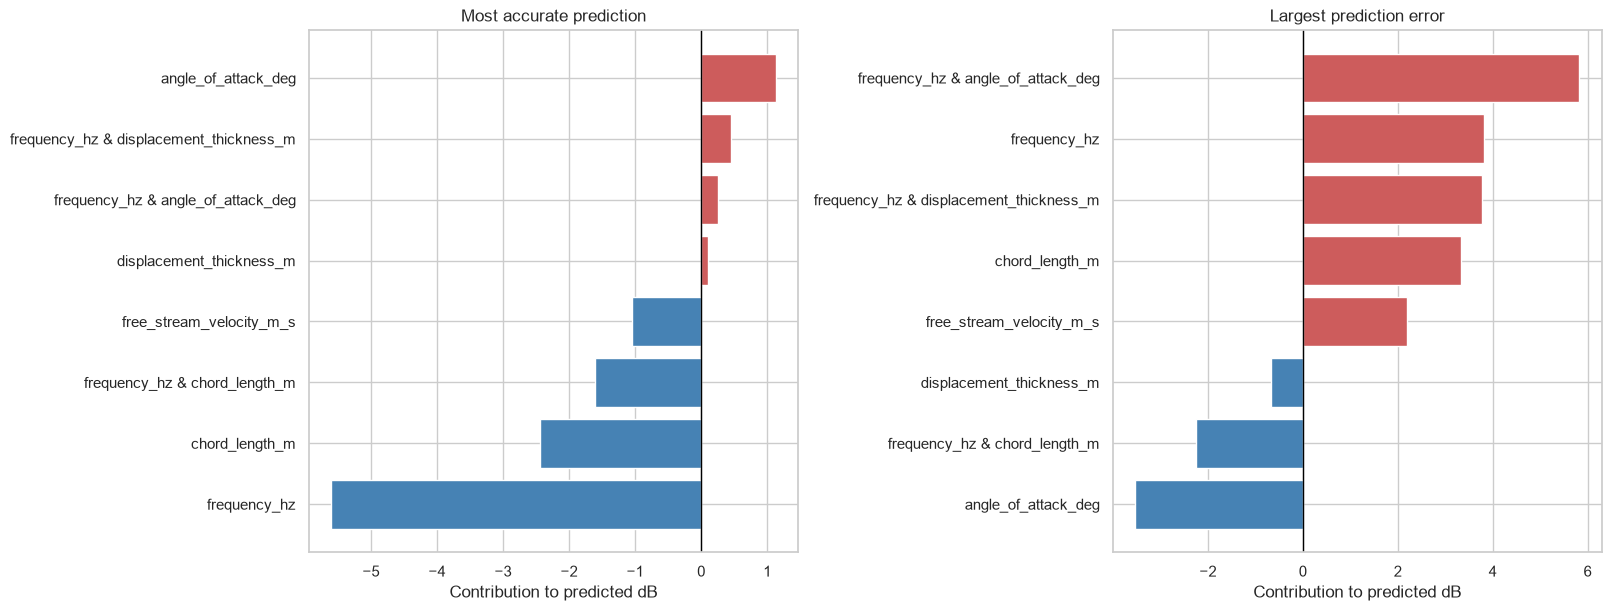

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for ax, (case_name, local_table) in zip(axes, local_tables.items()):
    plot_data = local_table.sort_values("contribution_db")
    colors = np.where(
        plot_data["contribution_db"] >= 0,
        "indianred",
        "steelblue"
    )

    ax.barh(plot_data["term"], plot_data["contribution_db"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set(
        title=case_name,
        xlabel="Contribution to predicted dB",
        ylabel=""
    )

plt.show()


## 9. Test one completely unseen operating configuration

One held-out configuration is selected from the test set. The model has never seen this exact combination of angle, chord length, velocity, and displacement thickness. We compare predicted and measured noise across its available frequencies.


In [22]:
test_configuration_ids = configuration_id.iloc[test_index]
selected_configuration = test_configuration_ids.value_counts().index[0]

configuration_rows = data.loc[
    configuration_id == selected_configuration
].sort_values("frequency_hz")

configuration_X = configuration_rows[features]
configuration_prediction = ebm.predict(configuration_X)

fixed_conditions = (
    configuration_rows[configuration_columns]
    .iloc[0]
    .to_frame("value")
)

print("Selected unseen configuration:", selected_configuration)
display(fixed_conditions.round(6))


Selected unseen configuration: 10


,value
angle_of_attack_deg,4.000000
chord_length_m,0.304800
free_stream_velocity_m_s,71.300000
displacement_thickness_m,0.004978


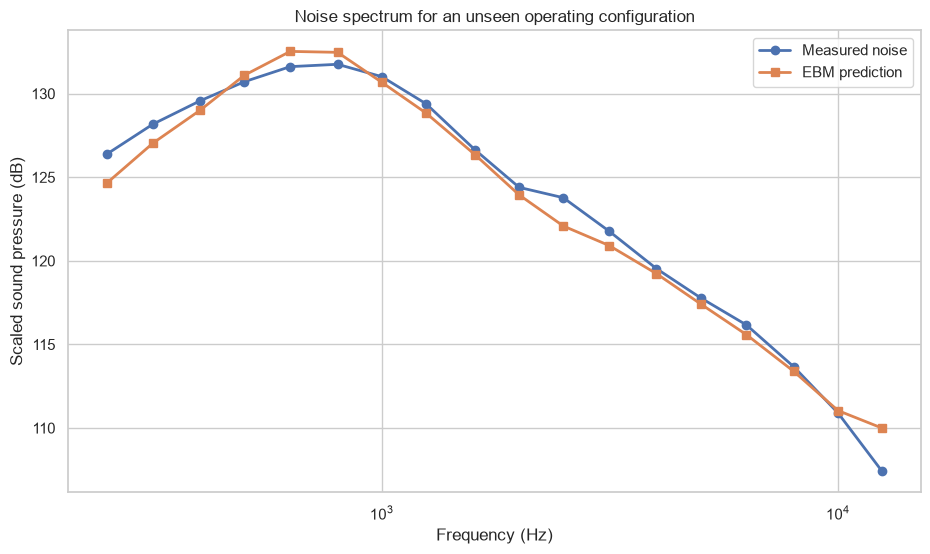

,metric,value_db
0,MAE,0.7705
1,RMSE,0.9930


In [23]:
plt.figure(figsize=(11, 6))

plt.plot(
    configuration_rows["frequency_hz"],
    configuration_rows["sound_pressure_db"],
    marker="o",
    linewidth=2,
    label="Measured noise"
)

plt.plot(
    configuration_rows["frequency_hz"],
    configuration_prediction,
    marker="s",
    linewidth=2,
    label="EBM prediction"
)

plt.xscale("log")
plt.title("Noise spectrum for an unseen operating configuration")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Scaled sound pressure (dB)")
plt.legend()
plt.show()

configuration_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value_db": [
        mean_absolute_error(
            configuration_rows["sound_pressure_db"],
            configuration_prediction
        ),
        mean_squared_error(
            configuration_rows["sound_pressure_db"],
            configuration_prediction
        ) ** 0.5
    ]
})

display(configuration_metrics.round(4))


## Local explanations and unseen configuration

### Individual predictions

The most accurate case has an actual value of **116.417 dB** and a prediction of **116.407 dB**, an error of only **0.010 dB**. Starting from the 125.174 dB intercept, the largest reductions come from frequency (−5.599 dB), chord length (−2.441 dB), frequency × chord length (−1.608 dB), and velocity (−1.044 dB). Angle of attack provides the largest positive contribution (+1.128 dB). Adding all main and interaction contributions to the intercept exactly reconstructs 116.407 dB.

The worst case has an actual value of **124.276 dB** but is predicted at **137.680 dB**, so the model overpredicts by **13.404 dB**. The largest positive contributions are frequency × angle (+5.828 dB), frequency (+3.825 dB), frequency × thickness (+3.779 dB), chord length (+3.339 dB), and velocity (+2.185 dB). These outweigh negative effects from angle (−3.531 dB), frequency × chord (−2.247 dB), and thickness (−0.673 dB). This case combines 800 Hz, a 17.4° angle, the minimum chord length, high velocity, and moderate thickness—an unseen and strongly interaction-dependent configuration. Its large error shows that an explanation can faithfully describe the model's reasoning even when that reasoning produces an inaccurate result.

### Unseen configuration

For held-out configuration 10 (4° angle, 0.3048 m chord, 71.3 m/s velocity, and 0.004978 m thickness), the EBM closely follows the measured spectrum. It captures the rise to a peak around 630–800 Hz and the sustained decline at higher frequencies. Its errors are small through most of the curve, with larger differences near the lowest and highest measured frequencies. The configuration-level **MAE is 0.7705 dB** and **RMSE is 0.9930 dB**, substantially better than the overall test metrics. This example demonstrates successful generalization to one unseen physical configuration, although it should not be assumed to represent all 22 held-out configurations.


## Final conclusions

### Predictive performance

The interaction EBM generalizes well to unseen operating configurations, achieving **MAE 2.5328 dB, RMSE 3.6577 dB, and $R^2$ 0.7246**. It clearly outperforms Ridge regression (3.6958 MAE, 4.9783 RMSE, and 0.4897 $R^2$) and the mean baseline (5.6788 MAE, 7.1518 RMSE, and −0.0530 $R^2$). The random forest produces the best RMSE and $R^2$ at 3.5619 dB and 0.7388, but EBM has the best MAE and remains very close overall.

The comparison between EBM variants is the main modeling result. Adding only three interactions reduces MAE by 28.7%, reduces RMSE by 23.3%, and raises $R^2$ by 0.1924 relative to the main-effects EBM. Aerodynamic noise is therefore not well represented by independent feature effects alone.

### Explainability

Frequency is the strongest main effect, and its contribution changes from positive at low frequencies to strongly negative at high frequencies. Longer chord lengths, larger angles, and thicker displacement layers generally reduce the fitted contribution after their respective thresholds, while higher free-stream velocity raises it. The strongest interaction is frequency × displacement thickness, followed by frequency × chord length and frequency × angle. Consequently, frequency must be interpreted together with the physical airfoil condition rather than as an isolated driver.

The local explanations reconstruct every prediction exactly from the intercept and eight learned terms. They are diagnostically useful as well as interpretable: the 13.404 dB worst-case error is traced mainly to large positive frequency-based interactions, revealing a specific feature-space region where more training experiments would be valuable.

### Generalization and limitations

The grouped split prevents the same operating configuration from appearing in both partitions, providing a stricter test than random row splitting. The selected unseen configuration is modeled particularly well, with 0.7705 dB MAE and 0.9930 dB RMSE, but other high-angle, small-chord, low-frequency configurations generate errors above 10 dB. Performance therefore varies substantially across the physical design space.

The dataset contains only 1,503 measurements from 106 configurations and one NACA 0012 airfoil family. Wind-tunnel conditions may not reproduce real aircraft, turbines, or fans, and a single group split cannot quantify variation across every possible holdout. The learned curves are adjusted predictive associations, not causal laws; their shaded ranges show bag-to-bag model variation rather than prediction intervals. Predictions should remain inside the observed ranges.

### Practical conclusion

EBM provides a strong compromise between predictive accuracy and engineering transparency. The random forest retains a small advantage on large-error-sensitive metrics, but EBM matches its typical absolute error while revealing nonlinear thresholds, physical interactions, and exact local reasoning. It could support early design screening and help identify operating regions requiring further wind-tunnel tests, but it should augment rather than replace aerodynamic expertise or validated physical simulation. A stronger follow-up would use repeated grouped cross-validation, configuration-level error reporting, and data from additional airfoil geometries.
